In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df_personagens = pd.read_csv('../datasets/personagens.csv')
df_personagens

,NOME,Status,Falas
0,A VOICE,Bloqueado,1
1,AEMON,Ativo,27
2,AERON,Ativo,9
3,AERSON,Ativo,1
4,AHSA,Ativo,2
...,...,...,...
508,YOUNG LYANNA,Ativo,3
509,YOUNG MAN,Bloqueado,1
510,YOUNG NED,Ativo,5
511,YOUNG RODRIK,Ativo,1


In [3]:
df_dicionario = pd.read_csv('../datasets/personagens_dicionario.csv')
df_dicionario

,NOME_OFICIAL,VARIACOES,FAMILIA_GRUPO,TOTAL_FALAS
0,TYRION LANNISTER,TRION|TYRIOM|TYRION|TYRION LANNISTER|TYRON|YTRION,Casa Lannister,1648
1,JON SNOW,JOHN|JON|JON SNOW,Night's Watch,1047
2,DAENERYS TARGARYEN,DAENERYS|DAENERYS TARGARYEN|DAERNEYS|DAEYNERYS...,Casa Targaryen,946
3,CERSEI LANNISTER,CERSEI|CERSIE|CESEI|ERSEI,Casa Lannister,921
4,JAIME LANNISTER,JAIME,Casa Lannister,909
...,...,...,...,...
269,WARG,WARG,Selvagens,1
270,WATCHMAN,WATCHMAN,Patrulha da Noite,1
271,WHITE RAT,WHITE RAT,Patrulha da Noite,1
272,WILDLING ELDER,WILDLING ELDER,Selvagens,1


In [4]:
df_dicionario[df_dicionario['NOME_OFICIAL'] == 'Tyrion Lannister']

,NOME_OFICIAL,VARIACOES,FAMILIA_GRUPO,TOTAL_FALAS


In [5]:
df_interacoes = pd.read_csv('../datasets/interacoes.csv', low_memory=False)
print(f'Total de interações: {len(df_interacoes):,}')
df_interacoes.head()

Total de interações: 28,958


,NTemporada,NEpisodio,NCena,falante,ouvinte,fala,tamanho_fala,descricao_cena,num_personagens_cena,tipo_interacao
0,1,1,0,WAYMAR ROYCE,YOHN ROYCE,What d’you expect? They’re savages. One lot st...,136,EPISODE 1 - WINTER IS COMING [First scene open...,4,group
1,1,1,0,WAYMAR ROYCE,WILL,What d’you expect? They’re savages. One lot st...,136,EPISODE 1 - WINTER IS COMING [First scene open...,4,group
2,1,1,0,WAYMAR ROYCE,GARED,What d’you expect? They’re savages. One lot st...,136,EPISODE 1 - WINTER IS COMING [First scene open...,4,group
3,1,1,0,WILL,YOHN ROYCE,I’ve never seen wildlings do a thing like this...,103,EPISODE 1 - WINTER IS COMING [First scene open...,4,group
4,1,1,0,WILL,WAYMAR ROYCE,I’ve never seen wildlings do a thing like this...,103,EPISODE 1 - WINTER IS COMING [First scene open...,4,group


## Análise de Grafos - Rede de Personagens

Agora vamos construir o grafo e aplicar algoritmos para responder:
**"Matematicamente, quem é o personagem mais importante da saga?"**

In [6]:
import networkx as nx
from collections import Counter

In [7]:
# Construir grafo ponderado usando as novas colunas
G = nx.Graph()

# Filtrar apenas interações diretas (1-para-1)
df_diretas = df_interacoes[df_interacoes['num_personagens_cena'] == 2].copy()

# Contar interações entre pares de personagens
interacoes = df_diretas[['falante_oficial', 'ouvinte_oficial']].dropna()

for _, row in interacoes.iterrows():
    falante = row['falante_oficial']
    ouvinte = row['ouvinte_oficial']
    
    if falante != ouvinte:  # Evitar self-loops
        if G.has_edge(falante, ouvinte):
            G[falante][ouvinte]['weight'] += 1
        else:
            G.add_edge(falante, ouvinte, weight=1)

print(f'Nós (personagens): {G.number_of_nodes()}')
print(f'Arestas (conexões): {G.number_of_edges()}')

KeyError: "None of [Index(['falante_oficial', 'ouvinte_oficial'], dtype='object')] are in the [columns]"

### 1. Métricas de Centralidade

Vamos calcular diferentes métricas para identificar os personagens mais importantes:

In [ ]:
# Centralidade de Grau (Degree Centrality)
degree_cent = nx.degree_centrality(G)

# Centralidade de Intermediação (Betweenness Centrality)
betweenness_cent = nx.betweenness_centrality(G, weight='weight')

# PageRank
pagerank = nx.pagerank(G, weight='weight')

# Criar DataFrame com resultados
centrality_df = pd.DataFrame({
    'Personagem': list(G.nodes()),
    'Grau': [degree_cent[n] for n in G.nodes()],
    'Intermediacao': [betweenness_cent[n] for n in G.nodes()],
    'PageRank': [pagerank[n] for n in G.nodes()]
})

# Ordenar por PageRank
centrality_df = centrality_df.sort_values('PageRank', ascending=False)

print('\n=== TOP 15 PERSONAGENS MAIS IMPORTANTES ===\n')
centrality_df.head(15)


=== TOP 15 PERSONAGENS MAIS IMPORTANTES ===



,Personagem,Grau,Intermediacao,PageRank
18,TYRION LANNISTER,0.264085,0.130359,0.059921
8,JON SNOW,0.190141,0.039604,0.041186
4,SANSA STARK,0.165493,0.075691,0.029057
14,CERSEI LANNISTER,0.158451,0.098283,0.029046
13,JAIME LANNISTER,0.161972,0.022065,0.028713
17,ARYA STARK,0.140845,0.227615,0.027888
44,SAMWELL TARLY,0.123239,0.023653,0.022989
12,THEON GREYJOY,0.140845,0.128152,0.022981
72,DAVOS SEAWORTH,0.147887,0.114815,0.019196
11,BRAN STARK,0.137324,0.103479,0.018785


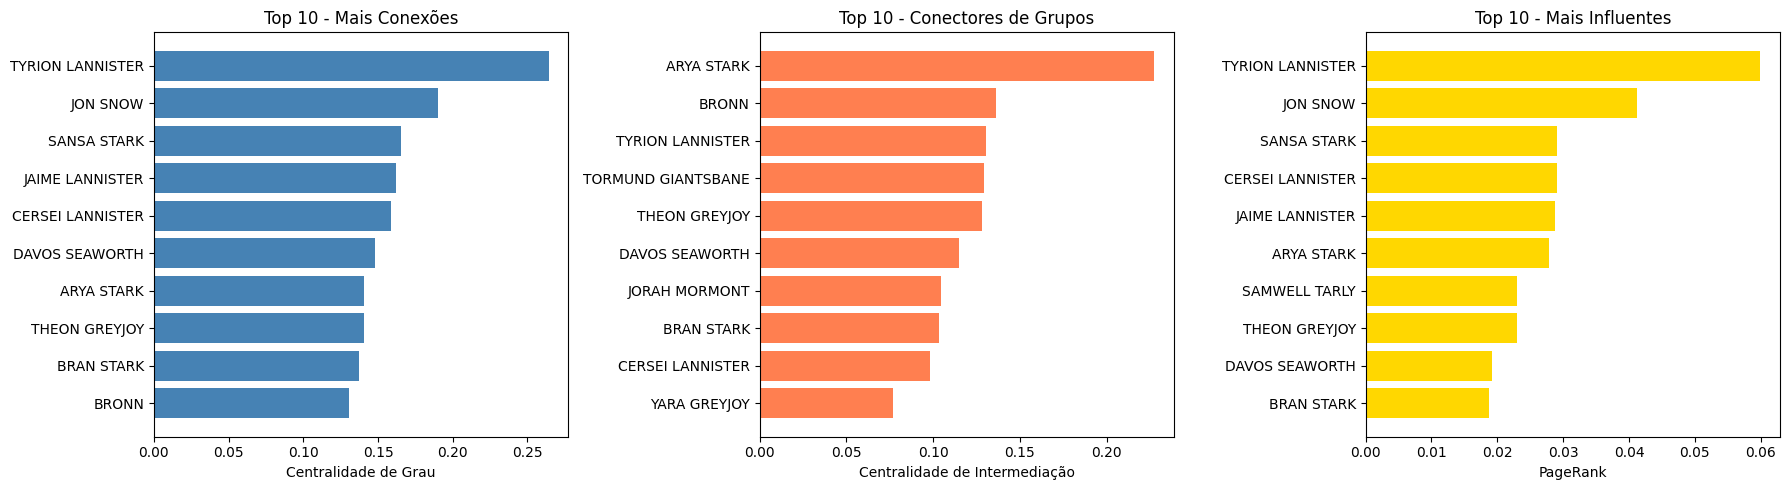

In [ ]:
# Visualizar Top 10 por cada métrica
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

top_n = 10

# Grau
top_degree = centrality_df.nlargest(top_n, 'Grau')
axes[0].barh(top_degree['Personagem'], top_degree['Grau'], color='steelblue')
axes[0].set_xlabel('Centralidade de Grau')
axes[0].set_title('Top 10 - Mais Conexões')
axes[0].invert_yaxis()

# Intermediação
top_between = centrality_df.nlargest(top_n, 'Intermediacao')
axes[1].barh(top_between['Personagem'], top_between['Intermediacao'], color='coral')
axes[1].set_xlabel('Centralidade de Intermediação')
axes[1].set_title('Top 10 - Conectores de Grupos')
axes[1].invert_yaxis()

# PageRank
top_pagerank = centrality_df.nlargest(top_n, 'PageRank')
axes[2].barh(top_pagerank['Personagem'], top_pagerank['PageRank'], color='gold')
axes[2].set_xlabel('PageRank')
axes[2].set_title('Top 10 - Mais Influentes')
axes[2].invert_yaxis()

plt.tight_layout()
plt.show()

### 2. Detecção de Comunidades

Identificar grupos de poder (famílias, alianças):

In [ ]:
from networkx.algorithms import community

# Detectar comunidades usando Louvain
communities = community.greedy_modularity_communities(G, weight='weight')

print(f'Número de comunidades detectadas: {len(communities)}\n')

# Mostrar as 5 maiores comunidades
for i, comm in enumerate(sorted(communities, key=len, reverse=True)[:5]):
    print(f'\nComunidade {i+1} ({len(comm)} membros):')
    print(', '.join(sorted(list(comm))[:15]))  # Primeiros 15 membros

Número de comunidades detectadas: 12


Comunidade 1 (62 membros):
ALTON LANNISTER, AREO, BANKER, BRIENNE OF TARTH, BRONN, BUYER, CERSEI LANNISTER, CESEI, DAISY, DANERYS, DORAN MARTELL, DORNISH LORD, ELLARIA SAND, EURON GREYJOY, GREGOR CLEGANE

Comunidade 2 (60 membros):
A VOICE, AERON, AHSA, BALON GREYJOY, BLACK LORREN, BOLTON BANNERMAN, BRAN STARK, BRYNDEN TULLY, CATELYN STARK, COLEN, DAGMER CLEFTJAW, DORNISH PRINCE, EDMURE TULLY, FARLEN, FIRST MATE

Comunidade 3 (50 membros):
ALLISER THORNE, BABY, BENJEN STARK, BOWEN MARSH, COOPER, CRASTER, DERRYK, DICKON TARLY, DIM DALBA, DONNEL, ED SHEERAN, EDDISON TOLLETT, GIANT, GILLY, GRENN

Comunidade 4 (46 membros):
AMORY LORCH, ANGUY, ARMORY, ARYA STARK, BERIC DONDARRION, BIANCA, BOBONO, CAMELLO, CLARENZO, EDDARD STARK, FARMER HAMLET, GENDRY, GERARD, GOLD CLOAK, HOT PIE

Comunidade 5 (32 membros):
BARRISTAN SELMY, BELICHO, CHAMPION, DAARIO NAHARIS, DAENERYS TARGARYEN, DOREAH, ELDER MEEREEN SLAVE, FENNESZ, GOATHERD, GREIZHEN, GREY WORM, HIZDAH

## 📊 Resposta à Pergunta de Negócio

### "Matematicamente, quem é o personagem mais importante?"

Baseado nas métricas calculadas:

1. **PageRank** (influência global): Identifica quem tem conexões com personagens importantes
2. **Centralidade de Grau**: Quem tem mais conexões diretas
3. **Centralidade de Intermediação**: Quem conecta diferentes grupos

O personagem no topo do ranking é o **mais importante matematicamente**.

In [ ]:
# Personagem mais importante
most_important = centrality_df.iloc[0]

print('=' * 60)
print('PERSONAGEM MAIS IMPORTANTE DE GAME OF THRONES')
print('=' * 60)
print(f'\n🏆 {most_important["Personagem"]}\n')
print(f'PageRank: {most_important["PageRank"]:.4f}')
print(f'Centralidade de Grau: {most_important["Grau"]:.4f}')
print(f'Centralidade de Intermediação: {most_important["Intermediacao"]:.4f}')
print('\n' + '=' * 60)

PERSONAGEM MAIS IMPORTANTE DE GAME OF THRONES

🏆 TYRION LANNISTER

PageRank: 0.0599
Centralidade de Grau: 0.2641
Centralidade de Intermediação: 0.1304



In [ ]:
df_interacoes = pd.read_csv('../datasets/dataset_interacoes_personagens.csv')
df_interacoes

,temporada,episodio,cena,descricao_cena,falante_oficial,ouvinte_oficial,fala,tamanho_fala,num_personagens_cena,tipo_interacao
0,1,1,0,[First scene opens with three Rangers riding t...,WAYMAR ROYCE,ROYCE,What d’you expect? They’re savages. One lot st...,136,4,group
1,1,1,0,[First scene opens with three Rangers riding t...,WAYMAR ROYCE,GARED,What d’you expect? They’re savages. One lot st...,136,4,group
2,1,1,0,[First scene opens with three Rangers riding t...,WAYMAR ROYCE,WILL,What d’you expect? They’re savages. One lot st...,136,4,group
3,1,1,0,[First scene opens with three Rangers riding t...,WILL,ROYCE,I’ve never seen wildlings do a thing like this...,103,4,group
4,1,1,0,[First scene opens with three Rangers riding t...,WILL,GARED,I’ve never seen wildlings do a thing like this...,103,4,group
...,...,...,...,...,...,...,...,...,...,...
24881,8,6,99,BRAN and PODRICK exit. Everyone sits back down.,BRONN,TYRION LANNISTER,I think that's a very presumptuous statement.,45,5,group
24882,8,6,99,BRAN and PODRICK exit. Everyone sits back down.,TYRION LANNISTER,BRONN,I once brought a jackass and a honeycomb into ...,56,5,group
24883,8,6,99,BRAN and PODRICK exit. Everyone sits back down.,TYRION LANNISTER,SAMWELL TARLY,I once brought a jackass and a honeycomb into ...,56,5,group
24884,8,6,99,BRAN and PODRICK exit. Everyone sits back down.,TYRION LANNISTER,DAVOS SEAWORTH,I once brought a jackass and a honeycomb into ...,56,5,group


In [ ]:

df_interacoes[df_interacoes['num_personagens_cena'] == 2].count()


temporada               12648
episodio                12648
cena                    12648
descricao_cena          12648
falante_oficial         12648
ouvinte_oficial         12648
fala                    12648
tamanho_fala            12648
num_personagens_cena    12648
tipo_interacao          12648
dtype: int64

In [ ]:
df_interacoes.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24886 entries, 0 to 24885
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   temporada             24886 non-null  int64 
 1   episodio              24886 non-null  int64 
 2   cena                  24886 non-null  int64 
 3   descricao_cena        24886 non-null  object
 4   falante_oficial       24886 non-null  object
 5   ouvinte_oficial       24886 non-null  object
 6   fala                  24886 non-null  object
 7   tamanho_fala          24886 non-null  int64 
 8   num_personagens_cena  24886 non-null  int64 
 9   tipo_interacao        24886 non-null  object
dtypes: int64(5), object(5)
memory usage: 1.9+ MB


In [ ]:
print(f'Total de interações: {len(df_interacoes):,}')
print(f'Personagens únicos (falantes): {df_interacoes.falante_oficial.nunique()}')
print(f'Personagens únicos (ouvintes): {df_interacoes.ouvinte_oficial.nunique()}')

Total de interações: 24,886
Personagens únicos (falantes): 285
Personagens únicos (ouvintes): 285
